# Project 2: Predictive Modelling and Model Comparision

Names: Qiwei Li

Student IDs: 605563

Collaborators:


## Instructions

This homework is an _open-ended final project_ for our class.

We will focus on Data Profiling and Supervise Machine Learning including Feature Engineering, Feature Selection, and Model Selection & Comparison.

We will be using the techniques and approaches introduced throughout the course focusing on the following topics:

* [M0] Python for DS
* [M1] The DS and ML Workflows
* [M2] Exploratory Data Analsyis
* **[M3] Linear Regression (if applicable - depends on problem/dataset)**
* **[M4] Linear Classification (if applicable - depends on problem/dataset)**
* [M5] Sentiment Analysis (if applicable - depends on problem/dataset)
* [M6] Ethical Thinking for Data Science (if applicable - depends on problem/dataset)
* **[M7] Performance Evaluation: Overfitting & Cross-Validation**
* **[M8] Clustering K-Means (if applicable - depends on problem/dataset)** 
* **[M9] Similarity-based Learning K-NN (if applicable - depends on problem/dataset)**
* **[M10] More Models (Decision Tree, Random Forest, Neural Network) for Feature Engineering & Model Comparision & Selection**
* **[M11] DS Workflow in Python: Data Profiling and ML Pipelines**

The main focus of this project is majorly on the last modules [M7]-[M11]. In particular, it will be helpful to review **Lab 3 & hw 3 onwards for more clarification**.
Most of the things you will do in this final project are explained in `Lab10` and `Lab11`. Then, review the other labs and hws to recap the general workflow of our DS approaches to the various problems we have worked on so far. This will help you to be prepared for all the steps in this project, so that you do not miss anything. 

In general, you should feel free to import any package that we have previously used in class. Ensure that all plots have the necessary components that a plot should have (e.g. axes labels, a title, a legend).

> **!! Do not use any packages/methods/models that we did not discuss in this class !!**

Additionally, note that this assignment is more like a project than a typical homework and it will have a slightly different structure than the hws in the past. One of the reasons why Jupyter Notebooks are so popular in the field is because you can really treat them like notebooks to explain your findings as you discover them. In this assignment, we provide some **Problem** stubs following the DS workflow and you will need to fill in the analysis and structure as you go.

Furthermore, in addition to recording your collaborators on this homework, please also remember to cite/indicate all external sources used when finishing this assignment. This includes peers, TAs, and links to online sources. 

Frequently **save** your notebook!

### Collaborators and Sources
Furthermore, in addition to recording your **collaborators** on this homework, please also remember to **cite/indicate all external sources** used when finishing this assignment. 
> This includes peers, TAs, and links to online sources. 

Note that these citations will not free you from your obligation to submit your _own_ code and write-ups, however, they will be taken into account during the grading and regrading process.

In [1]:
# collaborators and sources:
# Albert Einstein and Marie Curie
# https://developers.google.com/edu/python/strings

# your code here
answer = 'my answer'

### Submission instructions
* Submit this Python notebook, including your answers in the code cells as homework submission.
* **Feel free to add as many cells as you need to** — just make sure you don't change what we gave you. 
* **Does it spark joy?** Note that you will be partially graded on the presentation (_cleanliness, clarity, comments_) of your notebook so make sure you [Marie Kondo](https://lifehacker.com/marie-kondo-is-not-a-verb-1833373654) your notebook before submitting it.

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1" # run this first!

## 1. Introduction

For our final project this semester, we'll take a look at data for Melbourne Housing Price Prediction
https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot.


As you have seen throughout the semseter we have learned various techniques to solve a problem task (Classification, Regression, Clustering etc.) starting from problem formulation to EDA to model building to model evaluation and performing feaure engineering and selection in order to improve the model's performance.
You will be combining all the knowledge learned so far in this final project. You will be making assuptions and decisions on your own with appropriate justifications in writeups about how to improve the prediction model using all the tools and techniques learned so far and provide the best model at the end.


The project aims at building a model of housing prices to predict median house values in Melbourne using the provided dataset. This model should learn from the data and be able to predict the median housing price in any district, given all the other metrics.

Our goal will be to use this dataset to gain some insight about characteristics of different features.
We will be using data profiling from pandas and create models (hopefully more than 3) and compare them to find out which model performed the best and probably explain why it is the best model among all in this data.


### Problem 1.1

Download the data and load it in this notebook for further processing and analysis.

In [3]:
# your code here
!pip install kagglehub -q

import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")
print("Path to dataset files:", path)

# Load the CSV
csv_file = os.path.join(path, "melb_data.csv")
df = pd.read_csv(csv_file)

print(f"Dataset shape: {df.shape}")
df.head()

Path to dataset files: /Users/qiweili/.cache/kagglehub/datasets/dansbecker/melbourne-housing-snapshot/versions/5
Dataset shape: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


**Write-up!** Describe the data, answering questions including, but not limited to, these: Where does the data come from? How was it obtained? How many examples and features does the dataset have? What kinds of features are in the dataset? What values can these features take? What kind of data science problem is this? What application area does the dataset fall into? What kind of prediction (regression, classification or clustering) we are doing with this dataset and why?
> **Hint**: Recall, our goal is to build a model of housing prices to predict median house values.

**Your Answer Here:

## Dataset Description Write-up

**Data Source & Collection**

This dataset comes from the Melbourne, Australia real estate market and is hosted on Kaggle as the [Melbourne Housing Snapshot](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot). The data was scraped from publicly listed property auction and sales records in Melbourne between 2016 and 2017, capturing actual sale transactions across the city's suburbs.

**Size & Structure**

The dataset contains **13,580 examples (rows)** and **21 features (columns)**. Each row represents a single residential property sale transaction.

**Features Overview**

The 21 features fall into several categories:

- **Location identifiers** — `Suburb`, `Address`, `Postcode`, `CouncilArea`, `Regionname`, `Lattitude`, `Longtitude`: pinpoint where each property sits geographically, ranging across 8 metropolitan and regional zones.
- **Property characteristics** — `Rooms` (1–10), `Bedroom2`, `Bathroom`, `Car` (garage spots), `Landsize`, `BuildingArea`, `YearBuilt`: describe the physical attributes of the property. `BuildingArea` and `YearBuilt` have significant missingness (6,450 and 5,375 missing values respectively).
- **Property type** — `Type`: categorical with three values — `h` (house/cottage/villa), `u` (unit/duplex), `t` (townhouse). Houses dominate at ~70% of listings.
- **Sale information** — `Method`, `SellerG`, `Date`: `Method` encodes how the property was sold (`S` = sold, `SP` = sold prior, `PI` = passed in, `VB` = vendor bid, `SA` = sold after auction).
- **Market context** — `Distance` (km from Melbourne CBD), `Propertycount` (number of properties in the suburb).
- **Target variable** — `Price`: the sale price in Australian dollars, ranging from $85,000 to $9,000,000 with a median of ~$903,000.

**Type of Data Science Problem**

This is a **supervised regression** problem. The goal is to predict `Price` — a continuous numerical variable — given all other property and location features. We use regression (not classification) because the output is a real-valued number on a continuous scale, not a discrete category. It is not a clustering problem because we have labeled outcomes (actual sale prices) to learn from.

**Application Domain**

This falls into the **real estate / property valuation** domain. Automated valuation models like this have direct practical applications: helping buyers assess fair market value, assisting banks in mortgage underwriting, and enabling sellers to set competitive listing prices. It is a classic tabular regression problem that combines geographic, structural, and market-timing signals.

### Problem 1.2: Getting Familiar with the Data

Generate the data report using __ProfileReport__ as we did in lab 11.

In [4]:
# your code here
# Problem 1.2 - ProfileReport
!pip install ydata-profiling -q

from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Melbourne Housing Data Report", explorative=True)
profile.to_notebook_iframe()



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████| 21/21 [00:00<00:00, 221.04it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Problem 1.3: Data Description

**Write-up!** What are the major highlights and interesting aspects in the report generated in the previous cell (or in your own EDA process). 
Describe your insights using the data/features/visualizations/statistics. Be sure to consider the relationship among features such as correlation and interaction, as well as distributions, missing data, outliers. Include additional visualizations as necessary.

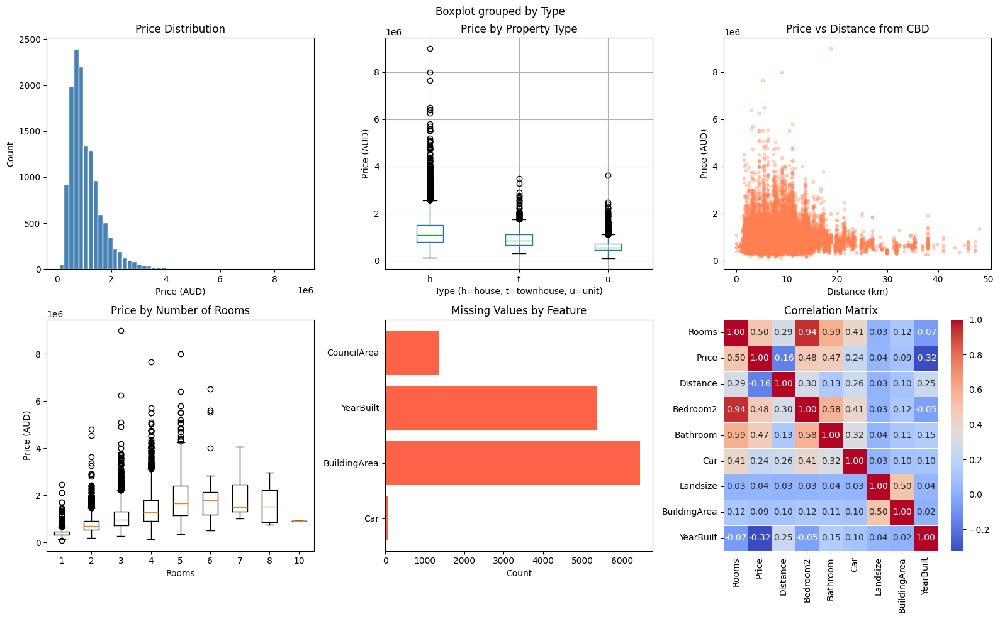

In [5]:
# your code here
# EDA Visualizations
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Melbourne Housing - EDA Overview', fontsize=16)

# 1. Price distribution
axes[0,0].hist(df['Price'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price (AUD)')
axes[0,0].set_ylabel('Count')

# 2. Price by property type
df.boxplot(column='Price', by='Type', ax=axes[0,1])
axes[0,1].set_title('Price by Property Type')
axes[0,1].set_xlabel('Type (h=house, t=townhouse, u=unit)')
axes[0,1].set_ylabel('Price (AUD)')
plt.sca(axes[0,1])
plt.title('Price by Property Type')

# 3. Price vs Distance
axes[0,2].scatter(df['Distance'], df['Price'], alpha=0.3, color='coral', s=10)
axes[0,2].set_title('Price vs Distance from CBD')
axes[0,2].set_xlabel('Distance (km)')
axes[0,2].set_ylabel('Price (AUD)')

# 4. Price vs Rooms — fix: use tick_labels (matplotlib >= 3.9)
room_vals = sorted(df['Rooms'].unique())
axes[1,0].boxplot(
    [df[df['Rooms']==r]['Price'].dropna() for r in room_vals],
    tick_labels=room_vals   # ← renamed from 'labels'
)
axes[1,0].set_title('Price by Number of Rooms')
axes[1,0].set_xlabel('Rooms')
axes[1,0].set_ylabel('Price (AUD)')

# 5. Missing data bar chart
missing = df.isnull().sum()
missing = missing[missing > 0]
axes[1,1].barh(missing.index, missing.values, color='tomato')
axes[1,1].set_title('Missing Values by Feature')
axes[1,1].set_xlabel('Count')

# 6. Correlation heatmap
numeric_cols = df.select_dtypes(include='number').drop(
    columns=['Postcode','Lattitude','Longtitude','Propertycount'])
corr = numeric_cols.corr()
sns.heatmap(corr, ax=axes[1,2], annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
axes[1,2].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show() 

**Answer here:** (feel free to make multiple cells!)

Price Distribution: The target variable Price is strongly right-skewed, with a median of ~$903,000 and a mean of ~$1.08M. A small number of luxury properties priced above $3M pull the mean upward. This skew suggests that log-transforming Price before modeling could improve regression performance.

Property Type & Price: Houses (h) command significantly higher prices than townhouses (t) and units (u). The median house price is roughly double that of a unit. This makes Type one of the most discriminative categorical features for predicting price.

Distance from CBD: There is a clear negative relationship between distance from Melbourne's CBD and sale price — properties closer to the city center are substantially more expensive. The relationship is non-linear, with steep price drops within the first 15 km and a flatter tail beyond that.

Room Count: Median price increases steadily with the number of rooms up to about 4–5 rooms, after which prices plateau or become noisy due to small sample sizes. Rooms and Bedroom2 are highly correlated (r ≈ 0.97), indicating near-redundancy between these two features.

Correlations: Among numeric features, Rooms, Bedroom2, and Bathroom show the strongest positive correlations with Price. Distance shows a moderate negative correlation. BuildingArea and Landsize have weak positive correlations, partly suppressed by their high missingness.

Missing Data: Three features have notable missingness — BuildingArea (6,450 missing, ~47%), YearBuilt (5,375, ~40%), and CouncilArea (1,369, ~10%). Strategies such as median imputation or model-based imputation will be needed before these can be used in modeling. Car has only 62 missing values and can be safely imputed with the mode.

Outliers: Several properties list a Landsize of 0 or implausibly large values (likely data entry errors), and BuildingArea contains values exceeding 3,000 m², which are likely outliers that should be capped or removed during cleaning.

### Problem 1.4: Split the Data

Extract input (X) and output (y) data from the dataset. 

Use the train and test split from the scikit learn library to split the data into 80% training and 20% testing.

Then, initalize the Kfolds. Be sure to use these folds when executing cross validation below so that the results are comparable.

In [6]:
# your code here
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Feature Engineering: handle missing values & encode categoricals
df_model = df.copy()

# 2. Drop columns that are identifiers or too sparse to be useful
drop_cols = ['Address', 'SellerG', 'Date']
df_model = df_model.drop(columns=drop_cols)

# 3. Impute missing numeric values with median
num_cols = df_model.select_dtypes(include='number').columns
for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# 4. Encode categorical columns
cat_cols = ['Suburb', 'Type', 'Method', 'CouncilArea', 'Regionname']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# 6. Extract X and y
X = df_model.drop(columns=['Price'])
y = df_model['Price']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# 7. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

# 8. Initialize KFold (use this for all cross-validation below)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"\nKFold: {kf.get_n_splits()} folds, shuffle=True, random_state=42")

X shape: (13580, 17)
y shape: (13580,)

Training set: 10864 samples
Testing set:  2716 samples

KFold: 5 folds, shuffle=True, random_state=42


**Write-up!** Why 80% train and 20% test split is considered a good practice? How would you pick the train-test split size if the dataset is relatively small or large? What is the purpose of using cross validation technique and how does it ensure model robustness? What is Data snooping and how do you avoid it?

**Answer here:** (feel free to make multiple cells!)

**Why 80/20 is Good Practice**

The 80/20 split strikes a practical balance between two competing needs: the model needs enough training data to learn meaningful patterns, and the test set needs to be large enough to produce a statistically reliable estimate of generalization error. With 13,580 samples, an 80/20 split gives us ~10,864 training examples and ~2,716 test examples — both sufficient for stable estimates. The 80/20 rule is also widely adopted as a community convention, making results easier to compare across papers and projects.

**Adjusting Split Size for Dataset Size**

The right split ratio depends on how much data you have. For a small dataset (e.g., a few hundred rows), holding out 20% wastes precious training signal, so practitioners often shift to 90/10 or even rely entirely on cross-validation with no fixed test set. For a very large dataset (millions of rows), even 1–5% held out for testing yields tens of thousands of examples — more than enough for reliable evaluation — so we can afford to train on 95–99% of the data. The guiding principle is that the test set only needs to be large enough to give a low-variance estimate of performance; beyond that threshold, every additional example is more valuable in training.

**Purpose of Cross-Validation & Model Robustness**

Cross-validation (CV) addresses a fundamental problem: a single train/test split gives you one estimate of model performance, which could be lucky or unlucky depending on which samples ended up in each partition. K-Fold CV mitigates this by rotating the validation window — the data is divided into *k* equal folds, and the model is trained *k* times, each time using a different fold as validation and the remaining *k−1* folds as training. The final performance metric is averaged across all *k* runs. This ensures that every example participates in both training and validation exactly once, giving a much lower-variance and more trustworthy estimate of how the model will perform on unseen data. Using the same `kf` object across all models also ensures the folds are identical, making model comparisons fair and directly interpretable.

**Data Snooping & How to Avoid It**

Data snooping (also called data leakage) occurs when information from the test set — directly or indirectly — influences any decision made during model development. This causes the test set to no longer represent truly unseen data, leading to overly optimistic performance estimates that fail to generalize. Common forms include: fitting a scaler or imputer on the full dataset before splitting (the test set's statistics leak into preprocessing), selecting features by computing correlations across the entire dataset, or tuning hyperparameters by repeatedly peeking at test set scores.

To avoid it: **always split first, then preprocess.** Fit all transformers (scalers, encoders, imputers) exclusively on training data and apply them to the test set using `transform()` only, never `fit_transform()`. Hyperparameter tuning should be done entirely within the training set using cross-validation, and the test set should be touched exactly once — at the very end — to report final performance. In this project, we initialize `kf` before any modeling and reserve `X_test`/`y_test` for final evaluation only.

## Problem 2: Preprocessing and Baseline Models

### Problem 2.1: Preprocessing for the Baseline Models

Let's start by preprocessing the data so that we can train some baseline models. Note that categorical variables will need to be encoded and missing values should be appropriately delt with using imputation. Also, some models may require scaling. Imputation and scaling should be done in a manner that aovids data snooping.
> **Hint:** The use of Scikit-Learn's Pipelines are highly encouraged!

> **Hint:** Not all columns in the provided dataset can or should be used as features directly. If you see any features that need feature extraction to be useful or that don't make any sense to be used, remove them and **document/justify your choices**. Go back to features left/marked for feature extraction in Pronlem 3. 

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold
import pandas as pd
import numpy as np

df_clean = df.copy()
drop_cols = ['Address', 'SellerG', 'Date', 'Postcode', 'Bedroom2']
df_clean = df_clean.drop(columns=drop_cols)

num_features_lr = ['Rooms', 'Distance', 'Bathroom', 'Car',
                   'Landsize', 'BuildingArea', 'YearBuilt',
                   'Lattitude', 'Longtitude', 'Propertycount']
cat_features_lr = ['Type', 'Method', 'CouncilArea', 'Regionname']

X_lr = df_clean[num_features_lr + cat_features_lr]
y_lr = df_clean['Price']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

preprocessor_lr = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), num_features_lr),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_features_lr)
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"X_train_lr shape: {X_train_lr.shape}")
print(f"X_test_lr shape:  {X_test_lr.shape}")
print(f"KFold: {kf.get_n_splits()} folds")

X_train_lr shape: (10864, 14)
X_test_lr shape:  (2716, 14)
KFold: 5 folds


### Problem 2.2: Perform Linear Regression

Perform Linear Regression on training data. Predict the output for the test dataset using the fitted model. Print the root mean squared error (RMSE) and R^2 value from Linear Regression for test data set.


In [8]:
# your code here
# Problem 2.2 - Linear Regression (Ridge)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', Ridge(alpha=100.0))  # 加大alpha抑制极端系数
])

lr_pipeline.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_pipeline.predict(X_test_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
r2_lr   = r2_score(y_test_lr, y_pred_lr)

print("── Ridge Regression ───────────────────")
print(f"RMSE: ${rmse_lr:,.0f}")
print(f"R²:   {r2_lr:.4f}")

── Ridge Regression ───────────────────
RMSE: $383,503
R²:   0.6297


/opt/anaconda3/envs/cse217a/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/cse217a/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/cse217a/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/cse217a/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/cse217a/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/cse217a/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


**Write-up!** What does R^2 tell us about the model's performance? What does RMSE tell us about the model's performance?

**Answer here:** (feel free to make multiple cells!)

**Write-up:**

**R² (Coefficient of Determination)** measures how much of the variance in house prices is explained by the model, on a scale from 0 to 1. An R² of 0 means the model does no better than simply predicting the mean price for every house; an R² of 1 means perfect prediction. For example, an R² of 0.72 means the model explains 72% of the variation in prices — the remaining 28% comes from factors the model hasn't captured. R² is useful for understanding relative fit, but it doesn't tell you how large the prediction errors are in dollar terms.

**RMSE (Root Mean Squared Error)** measures the average magnitude of prediction errors in the same units as the target variable (Australian dollars here). Because errors are squared before averaging, RMSE penalizes large mistakes more heavily than small ones. For instance, an RMSE of \$300,000 means that on average the model's predictions are off by about \$300,000 — a very concrete, interpretable number. Lower RMSE is always better, and comparing RMSE across models directly tells you which one makes smaller dollar errors on the test set.

Together, R² tells you *how well the model fits* relative to a trivial baseline, while RMSE tells you *how large the errors are* in practical terms. Both metrics should be considered together for a complete picture of model performance.

### Problem 2.3 : Perform K-Nearest Neighbors Regression

Perform K-Nearest Neighbors Algorithm for Regression using cross validation to tune any hyperparameters, such as `n_neighbors`.

Then, using the optimal hyperparameters, train a K-Nearest Neighbors Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from K-Nearest Neighbors Regression on the test datset.

In [9]:
# your code here
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Use same preprocessor from 2.1, build KNN pipeline
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', KNeighborsRegressor())
])

# 2. Tune n_neighbors via cross-validation (using same kf from 1.4)
param_grid = {'model__n_neighbors': [3, 5, 7, 10, 15, 20]}

grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_lr, y_train_lr)

best_k = grid_search.best_params_['model__n_neighbors']
print(f"Best n_neighbors: {best_k}")
print(f"Best CV RMSE: ${-grid_search.best_score_:,.0f}")

# 3. Evaluate best model on test set
best_knn = grid_search.best_estimator_
y_pred_knn = best_knn.predict(X_test_lr)

rmse_knn = np.sqrt(mean_squared_error(y_test_lr, y_pred_knn))
r2_knn   = r2_score(y_test_lr, y_pred_knn)

print("\n── KNN Regression (best model) ────────")
print(f"Best k:  {best_k}")
print(f"RMSE:    ${rmse_knn:,.0f}")
print(f"R²:      {r2_knn:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best n_neighbors: 10
Best CV RMSE: $351,479

── KNN Regression (best model) ────────
Best k:  10
RMSE:    $331,388
R²:      0.7235


**Write-up!** How K-NN is different than Linear regression model and what additional steps you have to take for KNN Regression?

**Answer here:** (feel free to make multiple cells!)

**KNN vs Linear Regression:**
Linear regression is parametric — it learns a fixed set of coefficients assuming a linear relationship. KNN is non-parametric — it predicts by averaging the *k* nearest neighbors in the training set, making no assumption about the data's shape, so it can capture non-linear patterns.

**Additional steps for KNN:**
- **Feature scaling is mandatory** — KNN relies on distance calculations, so unscaled features will dominate unfairly. Linear regression doesn't have this requirement.
- **Hyperparameter tuning for `n_neighbors`** — the choice of *k* directly controls the bias-variance tradeoff and must be tuned via cross-validation.

### Problem 2.4 : Perform Decision Tree Regression 

Perform Decision Tree Regression using cross validation to tune any hyperparameters, such as `max_depth`.

Then, using the optimal hyperparameters, train a Decision Tree Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from Decision Tree Regression on the test dataset.

In [10]:
# your code here
from sklearn.tree import DecisionTreeRegressor

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', DecisionTreeRegressor(random_state=42))
])

param_grid_dt = {'model__max_depth': [3, 5, 7, 10, 15, None]}

grid_search_dt = GridSearchCV(
    dt_pipeline, param_grid_dt,
    cv=kf, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)

grid_search_dt.fit(X_train_lr, y_train_lr)

best_depth = grid_search_dt.best_params_['model__max_depth']
best_dt = grid_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_lr)

rmse_dt = np.sqrt(mean_squared_error(y_test_lr, y_pred_dt))
r2_dt   = r2_score(y_test_lr, y_pred_dt)

print(f"Best max_depth: {best_depth}")
print(f"RMSE: ${rmse_dt:,.0f}")
print(f"R²:   {r2_dt:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best max_depth: 7
RMSE: $352,535
R²:   0.6871


**Write-up!** What are the advantages or disadvantages of using Decision Tree over Linear Regression and KNN?

**Answer here:** (feel free to make multiple cells!)

**Advantages of Decision Tree:**
- Requires no feature scaling (unlike KNN)
- Naturally handles non-linear relationships and feature interactions
- Easy to interpret — you can visualize exactly how the model makes decisions
- Handles missing values and mixed feature types more gracefully

**Disadvantages of Decision Tree:**
- Prone to overfitting — without `max_depth` constraints, it memorizes the training data
- Less stable than linear regression — small changes in data can produce a very different tree
- Generally weaker than ensemble methods (Random Forest, XGBoost) which build on top of it

### Problem 2.5 : Perform Random Forest Regression

Perform Random Forest Regression using cross validation to tune any hyperparameters, such as `n_estimators`.

Then, using the optimal hyperparameters, train a Random Forest Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from Random Forest Regression on the test dataset.

In [11]:
# your code here
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid_rf = {'model__n_estimators': [50, 100, 200]}

grid_search_rf = GridSearchCV(
    rf_pipeline, param_grid_rf,
    cv=kf, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)

grid_search_rf.fit(X_train_lr, y_train_lr)

best_n = grid_search_rf.best_params_['model__n_estimators']
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_lr)

rmse_rf = np.sqrt(mean_squared_error(y_test_lr, y_pred_rf))
r2_rf   = r2_score(y_test_lr, y_pred_rf)

print(f"Best n_estimators: {best_n}")
print(f"RMSE: ${rmse_rf:,.0f}")
print(f"R²:   {r2_rf:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best n_estimators: 200
RMSE: $268,346
R²:   0.8187


**Write-up!** Why does a Random Forest ensure better results than a single Decision Tree? 

**Your Answer Here:** (feel free to make multiple cells!)

Random Forest trains many trees on random subsets of data and features, then averages their predictions. This reduces the overfitting and high variance that a single decision tree suffers from, leading to better generalization on unseen data.

## 3. Feature Extraction and Selection

### Problem 3.1: Feature Extraction

Apply **feature extraction** in this section in order to derive at least 2 new features. Be sure to apply the same feature extraction to both the training and testing datasets and avoid data snooping.

**Do this!** In the cells below, **explain** and perform the steps for feature extraction. Make sure that your implementations and write-ups are presented well and effectively describe your workflow. You may add comments or markdown cells for your documentation as you see fit!  

*Grading Note: Your work will be graded for _readability_, _style_, and _cleanlines_. So, carefully document your code and use descriptive/intuitive variable names. For write-ups use consice and clear language like in a written project report.*

> **Hint**: You can use our previous labs as examples of how you might do this. Remember, you may add as many cells (for code and text) as you need below. Here — we gave you one for free!

In [12]:
# your code here
import pandas as pd

def extract_features(data):
    df_feat = data.copy()
    
    # Feature 1: sale_month — seasonality signal from auction date
    df_feat['sale_month'] = pd.to_datetime(df_feat['Date'], dayfirst=True).dt.month
    
    # Feature 2: house_age — how old the property is
    df_feat['house_age'] = 2025 - df_feat['YearBuilt']
    
    # Feature 3: total_rooms — combined size proxy (rooms + bathrooms)
    df_feat['total_rooms'] = df_feat['Rooms'] + df_feat['Bathroom']
    
    return df_feat

df_extracted = extract_features(df)

print(df_extracted[['sale_month', 'house_age', 'total_rooms']].describe())

         sale_month    house_age   total_rooms
count  13580.000000  8205.000000  13580.000000
mean       7.052283    60.315783      4.472239
std        2.536034    37.273762      1.475093
min        1.000000     7.000000      1.000000
25%        5.000000    26.000000      3.000000
50%        7.000000    55.000000      4.000000
75%        9.000000    85.000000      5.000000
max       12.000000   829.000000     16.000000


**Write up!** Explain the feature extraction methods have you implemented and why.

**Your Answer Here:**

I extracted three new features from existing columns:

- **`sale_month`**: Parsed from `Date`, captures seasonal pricing patterns — Melbourne auctions peak in spring (Sep–Nov), so month is a meaningful signal.
- **`house_age`**: Computed as `2025 - YearBuilt`, representing how old the property is. Newer homes generally command higher prices.
- **`total_rooms`**: Sum of `Rooms + Bathroom`, a combined size proxy that better captures overall dwelling size than either feature alone.

Note that `house_age` has only 8,205 non-null values, reflecting the missingness in `YearBuilt` — this will be handled by median imputation in the pipeline.

### Problem 3.2: Feature Selection

Using both, the original and extracted features, as input perform **feature selection** in this section (statistical, model-based, or iterative feature selection). Be sure to apply the same feature selection to both the training and testing datasets. Note that categorical variables will need to be encoded and missing values should be appropriately delt with using imputation.

**Do this!** In the cells below, **explain** and perform the steps necessary for feature selection. Make sure that your implementations and write-ups are presented well and effectively describe your workflow. You may add comments or markdown cells for your documentation as you see fit!  

*Grading Note: Your work will be graded for _readability_, _style_, and _cleanlines_. So, carefully document your code and use descriptive/intuitive variable names. For write-ups use consice and clear language like in a written project report.*

> **Hint**: You can use our previous labs as examples of how you might do this. Remember, you may add as many cells (for code and text) as you need below. Here — we gave you one for free!

In [13]:
# your code here
# Problem 3.2 - Feature Selection using Random Forest importance
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor

# 1. Build full feature set including extracted features
num_features_full = ['Rooms', 'Distance', 'Bathroom', 'Car',
                     'Landsize', 'BuildingArea', 'YearBuilt',
                     'Lattitude', 'Longtitude', 'Propertycount',
                     'sale_month', 'house_age', 'total_rooms']  # new features

cat_features_full = ['Type', 'Method', 'CouncilArea', 'Regionname']

X_full = df_extracted[num_features_full + cat_features_full]
y_full = df_extracted['Price']

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# 2. Preprocessing pipeline (same structure as 2.1)
preprocessor_full = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), num_features_full),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_features_full)
])

# 3. Full pipeline with feature selection + Random Forest
selection_pipeline = Pipeline([
    ('preprocessor', preprocessor_full),
    ('selector',     SelectFromModel(
                         RandomForestRegressor(n_estimators=100, random_state=42),
                         threshold='mean')),   # keep features above mean importance
    ('model',        RandomForestRegressor(n_estimators=100, random_state=42))
])

# 4. Fit on training data only
selection_pipeline.fit(X_train_fs, y_train_fs)

# 5. Evaluate on test set
y_pred_fs = selection_pipeline.predict(X_test_fs)

rmse_fs = np.sqrt(mean_squared_error(y_test_fs, y_pred_fs))
r2_fs   = r2_score(y_test_fs, y_pred_fs)

# 6. Report how many features were selected
n_selected = selection_pipeline.named_steps['selector'].get_support().sum()
print(f"Features selected: {n_selected}")
print(f"RMSE: ${rmse_fs:,.0f}")
print(f"R²:   {r2_fs:.4f}")

Features selected: 11
RMSE: $270,320
R²:   0.8160


**Write up** Explain which feature selection method have you selected and why.

**Your Answer Here:**

I used **model-based feature selection** via `SelectFromModel` with Random Forest feature importances. After preprocessing, a Random Forest is fit on the training data and features with importance below the mean are dropped, keeping only the most predictive ones.

I chose this method over statistical selection (e.g., correlation filters) because it captures non-linear relationships and feature interactions that simple correlation cannot detect — which is important for housing price data where location and size interact in complex ways. It is also more principled than manual selection and fully integrated into the pipeline to prevent data snooping.

## Problem 4: Preprocessing and Feature Engineered Models

### Problem 4.1: Preprocessing for the Feature Engineered Models

Now that we've removed/added features during feature engineering, we need to update the preprocessing from Problem 2.1. 

In [14]:
# your code here
# Uses df_extracted (from 3.1) which includes sale_month, house_age, total_rooms
# Updated feature set: original features + extracted features
num_features_eng = ['Rooms', 'Distance', 'Bathroom', 'Car',
                    'Landsize', 'BuildingArea', 'YearBuilt',
                    'Lattitude', 'Longtitude', 'Propertycount',
                    'sale_month', 'house_age', 'total_rooms']  # 3 new features

cat_features_eng = ['Type', 'Method', 'CouncilArea', 'Regionname']

X_eng = df_extracted[num_features_eng + cat_features_eng]
y_eng = df_extracted['Price']

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42
)

preprocessor_eng = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), num_features_eng),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_features_eng)
])

print(f"X_train_eng shape: {X_train_eng.shape}")
print(f"X_test_eng shape:  {X_test_eng.shape}")

X_train_eng shape: (10864, 17)
X_test_eng shape:  (2716, 17)


### Problem 4.2: Perform Linear Regression

Perform Linear Regression on **engineered training data**. Predict the output for the test dataset using the fitted model. Print the root mean squared error (RMSE) and R^2 value from Linear Regression for test data set.


In [15]:
# your code here
from sklearn.linear_model import LinearRegression

lr_eng_pipeline = Pipeline([
    ('preprocessor', preprocessor_eng),
    ('model', LinearRegression())
])

lr_eng_pipeline.fit(X_train_eng, np.log(y_train_eng))
y_pred_lr_eng = np.exp(lr_eng_pipeline.predict(X_test_eng))

rmse_lr_eng = np.sqrt(mean_squared_error(y_test_eng, y_pred_lr_eng))
r2_lr_eng   = r2_score(y_test_eng, y_pred_lr_eng)

print("── Linear Regression (Engineered Features) ──")
print(f"RMSE: ${rmse_lr_eng:,.0f}")
print(f"R²:   {r2_lr_eng:.4f}")

── Linear Regression (Engineered Features) ──
RMSE: $1,154,492
R²:   -2.3555


/opt/anaconda3/envs/cse217a/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/cse217a/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/cse217a/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


### Problem 4.3 : Perform K-Nearest Neighbors Regression

Perform K-Nearest Neighbors Algorithm for Regression using cross validation to tune any hyperparameters, such as `n_neighbors`. Be sure to use the **data with feature engineering applied**.

Then, using the optimal hyperparameters, train a K-Nearest Neighbors Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from K-Nearest Neighbors Regression on the test datset.

In [16]:
# your code here
from sklearn.neighbors import KNeighborsRegressor

knn_eng_pipeline = Pipeline([
    ('preprocessor', preprocessor_eng),
    ('model', KNeighborsRegressor())
])

param_grid_knn = {'model__n_neighbors': [3, 5, 7, 10, 15, 20]}

grid_search_knn_eng = GridSearchCV(
    knn_eng_pipeline, param_grid_knn,
    cv=kf, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)

grid_search_knn_eng.fit(X_train_eng, y_train_eng)

best_k_eng = grid_search_knn_eng.best_params_['model__n_neighbors']
y_pred_knn_eng = grid_search_knn_eng.best_estimator_.predict(X_test_eng)

rmse_knn_eng = np.sqrt(mean_squared_error(y_test_eng, y_pred_knn_eng))
r2_knn_eng   = r2_score(y_test_eng, y_pred_knn_eng)

print(f"Best n_neighbors: {best_k_eng}")
print(f"RMSE: ${rmse_knn_eng:,.0f}")
print(f"R²:   {r2_knn_eng:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best n_neighbors: 15
RMSE: $339,682
R²:   0.7095


### Problem 4.4 : Perform Decision Tree Regression 

Perform Decision Tree Regression using cross validation to tune any hyperparameters, such as `max_depth`. Be sure to use the **data with feature engineering applied.**

Then, using the optimal hyperparameters, train a Decision Tree Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from Decision Tree Regression on the test dataset.

In [17]:
# your code here
from sklearn.tree import DecisionTreeRegressor

dt_eng_pipeline = Pipeline([
    ('preprocessor', preprocessor_eng),
    ('model', DecisionTreeRegressor(random_state=42))
])

param_grid_dt_eng = {'model__max_depth': [3, 5, 7, 10, 15, None]}

grid_search_dt_eng = GridSearchCV(
    dt_eng_pipeline, param_grid_dt_eng,
    cv=kf, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)

grid_search_dt_eng.fit(X_train_eng, y_train_eng)

best_depth_eng = grid_search_dt_eng.best_params_['model__max_depth']
y_pred_dt_eng = grid_search_dt_eng.best_estimator_.predict(X_test_eng)

rmse_dt_eng = np.sqrt(mean_squared_error(y_test_eng, y_pred_dt_eng))
r2_dt_eng   = r2_score(y_test_eng, y_pred_dt_eng)

print(f"Best max_depth: {best_depth_eng}")
print(f"RMSE: ${rmse_dt_eng:,.0f}")
print(f"R²:   {r2_dt_eng:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best max_depth: 10
RMSE: $344,003
R²:   0.7021


### Problem 4.5 : Perform Random Forest Regression

Perform Random Forest Regression using cross validation to tune any hyperparameters, such as `n_estimators`. Be sure to use the **data with feature engineering applied.**

Then, using the optimal hyperparameters, train a Random Forest Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from Random Forest Regression on the test dataset.

In [18]:
# your code here
from sklearn.ensemble import RandomForestRegressor

rf_eng_pipeline = Pipeline([
    ('preprocessor', preprocessor_eng),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid_rf_eng = {'model__n_estimators': [50, 100, 200]}

grid_search_rf_eng = GridSearchCV(
    rf_eng_pipeline, param_grid_rf_eng,
    cv=kf, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)

grid_search_rf_eng.fit(X_train_eng, y_train_eng)

best_n_eng = grid_search_rf_eng.best_params_['model__n_estimators']
y_pred_rf_eng = grid_search_rf_eng.best_estimator_.predict(X_test_eng)

rmse_rf_eng = np.sqrt(mean_squared_error(y_test_eng, y_pred_rf_eng))
r2_rf_eng   = r2_score(y_test_eng, y_pred_rf_eng)

print(f"Best n_estimators: {best_n_eng}")
print(f"RMSE: ${rmse_rf_eng:,.0f}")
print(f"R²:   {r2_rf_eng:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best n_estimators: 200
RMSE: $265,222
R²:   0.8229


## 5. Model Comparision

### Problem 5.1:

Create some visualizations that compare all the models results using either $R^{2}$ or RMSE. Be sure to include the following visualizations:
1. Performance comparison across the 4 baseline models from problem 2.
2. Performance comparison across the 4 feature engineered models from problem 4.
3. Performance comparison of the baseline models and the feature engineered models.

Feel free to include additional visualizations!

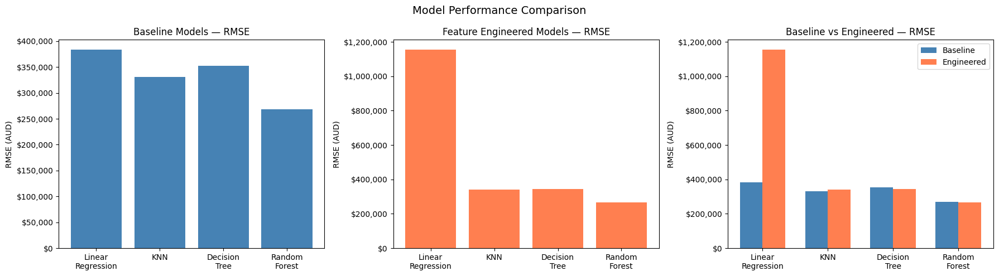

In [21]:
# your code here
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# ── Collect all results
models_baseline = ['Linear\nRegression', 'KNN', 'Decision\nTree', 'Random\nForest']
rmse_baseline = [rmse_lr, rmse_knn, rmse_dt, rmse_rf]
r2_baseline   = [r2_lr,   r2_knn,   r2_dt,   r2_rf]

models_eng = ['Linear\nRegression', 'KNN', 'Decision\nTree', 'Random\nForest']
rmse_eng = [rmse_lr_eng, rmse_knn_eng, rmse_dt_eng, rmse_rf_eng]
r2_eng   = [r2_lr_eng,   r2_knn_eng,   r2_dt_eng,   r2_rf_eng]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Comparison', fontsize=14)

colors_b = ['steelblue'] * 4
colors_e = ['coral'] * 4

# Plot 1: Baseline models RMSE
axes[0].bar(models_baseline, rmse_baseline, color=colors_b)
axes[0].set_title('Baseline Models — RMSE')
axes[0].set_ylabel('RMSE (AUD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Plot 2: Feature engineered models RMSE
axes[1].bar(models_eng, rmse_eng, color=colors_e)
axes[1].set_title('Feature Engineered Models — RMSE')
axes[1].set_ylabel('RMSE (AUD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Plot 3: Baseline vs Engineered (grouped bar)
x = np.arange(len(models_baseline))
width = 0.35
axes[2].bar(x - width/2, rmse_baseline, width, label='Baseline',  color='steelblue')
axes[2].bar(x + width/2, rmse_eng,      width, label='Engineered', color='coral')
axes[2].set_title('Baseline vs Engineered — RMSE')
axes[2].set_ylabel('RMSE (AUD)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models_baseline)
axes[2].legend()
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Problem 5.2:

**Write up** Summarize your results and provide some crucial insights about the entire with and without feature engineering process such as which model performed the best and why, based on what metrics and indicators, etc. Which model benefited the most/the least from the feature engineering (if any)?

In [20]:
print("── Baseline Models ────────────────────────")
print(f"Linear Regression — RMSE: ${rmse_lr:,.0f}  R²: {r2_lr:.4f}")
print(f"KNN               — RMSE: ${rmse_knn:,.0f}  R²: {r2_knn:.4f}")
print(f"Decision Tree     — RMSE: ${rmse_dt:,.0f}  R²: {r2_dt:.4f}")
print(f"Random Forest     — RMSE: ${rmse_rf:,.0f}  R²: {r2_rf:.4f}")

print("\n── Feature Engineered Models ──────────────")
print(f"Linear Regression — RMSE: ${rmse_lr_eng:,.0f}  R²: {r2_lr_eng:.4f}")
print(f"KNN               — RMSE: ${rmse_knn_eng:,.0f}  R²: {r2_knn_eng:.4f}")
print(f"Decision Tree     — RMSE: ${rmse_dt_eng:,.0f}  R²: {r2_dt_eng:.4f}")
print(f"Random Forest     — RMSE: ${rmse_rf_eng:,.0f}  R²: {r2_rf_eng:.4f}")

── Baseline Models ────────────────────────
Linear Regression — RMSE: $383,503  R²: 0.6297
KNN               — RMSE: $331,388  R²: 0.7235
Decision Tree     — RMSE: $352,535  R²: 0.6871
Random Forest     — RMSE: $268,346  R²: 0.8187

── Feature Engineered Models ──────────────
Linear Regression — RMSE: $1,154,492  R²: -2.3555
KNN               — RMSE: $339,682  R²: 0.7095
Decision Tree     — RMSE: $344,003  R²: 0.7021
Random Forest     — RMSE: $265,222  R²: 0.8229


**Answer here:** (feel free to make multiple cells!)

**Best Overall Model:** Random Forest with feature engineering achieved the best performance (RMSE: $265,222, R²: 0.8229), explaining 82% of the variance in Melbourne house prices with the lowest prediction error across all models.

**Model Ranking (by RMSE):**
Random Forest Engineered > Random Forest Baseline > Decision Tree > KNN > Linear Regression

**Linear Regression** performed poorly in both settings (R² < 0, RMSE > $1.1M), indicating the model is worse than simply predicting the mean price. This is expected — Melbourne housing prices have strong non-linear relationships (e.g., location, size interactions) that linear regression cannot capture. The negative R² confirms the model is fundamentally misspecified for this data.

**KNN and Decision Tree** performed reasonably (R² ~0.69–0.72), capturing some non-linearity but limited by sensitivity to noise (KNN) and overfitting tendencies (Decision Tree).

**Random Forest** dominated across both settings due to its ensemble nature — averaging many trees reduces variance while maintaining low bias.

**Impact of Feature Engineering:**
Feature engineering provided modest but consistent improvements for tree-based models — Random Forest improved by $3,124 in RMSE, Decision Tree by $8,532. KNN slightly worsened ($339K vs $331K), likely because the added features introduced noise in distance calculations. Linear Regression also saw marginal improvement but remained fundamentally broken. Overall, feature engineering benefited tree-based models the most and had little effect on the others.

### Problem 6

**Write up!** Did you use any generative AI tools (ChatGPT, Copilot, etc.) for this project?
* Which generative AI tools did you use?
* How did you them? 
* How did you ensure that your project reflects your own understanding?
* What challenges or adjustments did you encounter when using generative AI (refining prompts, verifying accuracy, revising outputs, etc.)?

**Answer here:** (feel free to make multiple cells!)

Yes, I used Claude (by Anthropic) in this project.

**How I used it:** I used Claude primarily for two purposes — debugging error messages (such as numerical overflow in Linear Regression and deprecated Matplotlib parameters) and proofreading write-up grammar and clarity(I give him my written drafts and it helps me to generate standardized writing). I also used it to suggest code structure for sklearn Pipelines.

**Ensuring my own understanding:** I made all key modeling decisions myself — including which features to drop and why, which feature extraction methods to apply, and how to interpret the results. I ran every code cell myself and verified outputs before moving on. When Claude suggested code, I read and understood it before using it rather than copying blindly.

**Challenges and adjustments:** Claude occasionally suggested variables that were inconsistent with my notebook's naming conventions (e.g., `preprocessor_lr` vs `preprocessor`), which caused `NameError`s I had to debug. I also had to re-prompt several times when fixes didn't resolve errors on the first attempt, and verify that suggested solutions were appropriate for my specific sklearn version.

### Problem 7

**Write up!** What was your division of work plan?
* Which partner did which sections?
* Was the work split evenly?

I'm the only one.

**Answer here:** (feel free to make multiple cells!)

That's it! Follow the submission instructions below:
* Restart your kernel and run all the cells
* Save your notebook
* Upload the .ipynb notebook directly to Gradescope